# Análise de camadas e poda (*layer pruning*) no GraphPFN

Este notebook reúne, em um único fluxo, **(1)** o que cada camada do GraphPFN faz, **(2)** a métrica de *Block Influence* (BI) usada para escolher camadas a podar e **(3)** a poda em si, com testes que dizem se ela é **válida**.

**Pergunta central:** dá para remover camadas do GraphPFN escolhidas por BI sem perder desempenho?

### Critérios de validade

A poda só vale como resultado se os quatro critérios abaixo forem atendidos. Cada seção testa um deles.

| # | Critério | Como é testado | Seção |
|---|---|---|---|
| V1 | O modelo completo (baseline) funciona: desempenho bem acima do acaso e próximo do pipeline oficial | pipeline oficial do pacote `graphpfn`, splits oficiais | 2 |
| V2 | O modelo podado retém o desempenho (≥ 95% do ganho sobre o acaso) | curvas de poda | 5 |
| V3 | Escolher camadas por BI é melhor que escolher ao acaso | BI contra 5 ordens aleatórias | 5 |
| V4 | BI baixo corresponde de fato a uma camada pouco importante | correlação de Spearman entre BI e ablação individual (*leave-one-layer-out*) | 4 |

**Desempenho retido.** Para comparar tarefas diferentes, a métrica principal é normalizada pelo nível de acaso:

$$\text{retido}(\%) = 100 \cdot \frac{s_{\text{podado}} - s_{\text{acaso}}}{s_{\text{completo}} - s_{\text{acaso}}}$$

com $s$ = ROC-AUC (binária, acaso 0,5), acurácia (multiclasse, acaso = frequência da classe majoritária no teste) ou $R^2$ (regressão, acaso 0). 100% = igual ao modelo completo, 0% = igual a chutar.

### Sumário
0. Configuração
1. Arquitetura: o que existe dentro de uma "camada"
2. Dados, pipeline oficial e baseline (V1)
3. Block Influence por camada e por sub-bloco
4. Ablação individual: importância real de cada camada (V4)
5. Curvas de poda: BI × aleatório × ablação (V2, V3)
6. Custo: parâmetros e latência
7. Veredito
8. Conclusões

## 0. Configuração

In [1]:
import os, sys, time, warnings
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
from pathlib import Path
from contextlib import contextmanager

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "src" / "graphpfn").exists() else cwd / "GraphFPN"
os.chdir(PROJECT_ROOT)  # LimiXWrapper procura ./checkpoints/LimiX-16M.ckpt
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl
import dgl.data
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

from graphpfn import GraphDataset, GraphPFN, GraphPFNLight
from graphpfn.inference.preprocessing import prepare_features_tensor, prepare_graph, standardize_targets
from graphpfn.inference.util import apply_model, compute_metrics

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT = PROJECT_ROOT / "checkpoints" / "graphpfn-adapters-1_3.pt"
GRAPHLAND_ROOT = Path.home() / ".cache" / "graphland"
RESULTS_DIR = PROJECT_ROOT.parent / "Block_Influence_results" / "graphfpn_analise_unificada"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Datasets avaliados em grafo completo com split oficial.
# d_pca=64 é o valor recomendado no README do GraphPFN para features de alta dimensão.
DATASETS = {
    "tolokers-2":   dict(source="graphland"),             # classificação binária
    "cora":         dict(source="planetoid", d_pca=64),   # multiclasse (7 classes)
    "pubmed":       dict(source="planetoid", d_pca=64),   # multiclasse (3 classes)
    "city-roads-M": dict(source="graphland"),             # regressão
    "artnet-views": dict(source="graphland"),             # regressão (~15 GB de GPU)
}
SEEDS = [0, 1, 2]        # sementes das features aleatórias e do positional embedding do LimiX
N_RANDOM_ORDERS = 5      # ordens aleatórias de poda (controle do critério V3)
N_LAYERS = 12
AMP = True               # bfloat16, igual ao predict_icl oficial
RECOMPUTE = False        # True = ignora os CSVs em cache e refaz os experimentos

PRIMARY_METRIC = {"binclass": "roc_auc", "multiclass": "accuracy", "regression": "r2"}
METRIC_LABEL = {"roc_auc": "ROC-AUC", "accuracy": "Acurácia", "r2": "R²"}

# Paleta categórica em ordem fixa (cor segue o dataset/estratégia, nunca o ranking)
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GRAY = "#8a8985"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
    "lines.linewidth": 2, "lines.markersize": 6, "font.size": 10,
})

print(f"Projeto:    {PROJECT_ROOT}")
print(f"Dispositivo: {DEVICE} ({torch.cuda.get_device_name() if DEVICE.type == 'cuda' else 'cpu'})")
print(f"Resultados: {RESULTS_DIR}")

Projeto:    /home/isabelly/Documentos/Graph_Pruning/GraphFPN
Dispositivo: cuda (NVIDIA GeForce RTX 5060 Ti)
Resultados: /home/isabelly/Documentos/Graph_Pruning/Block_Influence_results/graphfpn_analise_unificada


## 1. Arquitetura: o que existe dentro de uma "camada"

O GraphPFN é o modelo tabular **LimiX-16M** (um *prior-data fitted network*, PFN) com **adaptadores de grafo** inseridos após cada uma das suas 12 camadas. Os pesos do LimiX vêm de `LimiX-16M.ckpt`; os adaptadores vêm de `graphpfn-adapters-1_3.pt`.

```
features [N, F] ──► +8 features aleatórias ──► agrupa de 2 em 2 ──► encoder ──► h₀ : [1, N, G+1, 192]
                                                                                      │
       ┌──────────────────────── GraphPFNLayerWrapper (× 12) ─────────────────────────┤
       │  1. EncoderBaseLayer (LimiX, arquitetura "fmfmsm", pós-norm):                │
       │       atenção entre features → MLP → atenção entre features → MLP            │
       │       → atenção entre amostras (teste olha só treino) → MLP                  │
       │  2. conv: h + GraphAttention(LayerNorm(h))   (mensagens pelas arestas)       │
       │  3. mlp:  h + MLP(LayerNorm(h))                                              │
       └──────────────────────────────────────────────────────────────────────────────┘
                                                                                      │
              decoder lê SOMENTE o token-alvo (último) dos nós de teste ◄──────────────┘
```

- **Tokens.** Cada nó vira $G+1$ tokens de dimensão 192: $G = \lceil (F+8)/2 \rceil$ tokens de grupos de features e **1 token-alvo**, que carrega o rótulo para nós de treino e fica mascarado para nós de teste.
- **Predição.** Sai **apenas** do token-alvo dos nós de teste. Os tokens de feature são o "contexto" que alimenta esse token.
- **Aprendizado em contexto (ICL).** O modelo não é treinado no dataset: os nós de treino com rótulo entram como contexto e o modelo infere os rótulos do teste em um único forward.

Isso importa para a poda: se o BI for calculado como média sobre **todos** os $N \times (G+1)$ tokens, os tokens de feature (a grande maioria) dominam a média, enquanto a predição depende só do token-alvo.

In [2]:
BASE = GraphPFNLight()
_state = torch.load(CHECKPOINT, map_location="cpu", weights_only=True)["state_dict"]
BASE.load_state_dict(_state, strict=False)
BASE = BASE.eval().to(DEVICE)

def make_model(n_features, n_classes):
    """GraphPFN com 1 membro de ensemble, compartilhando os pesos de BASE."""
    return GraphPFN(BASE, n_members=1, n_features=n_features, n_classes=n_classes,
                    device=DEVICE, verbose=False).eval()

def get_layers(model):
    return model.base.tfm.module.transformer_encoder.layers

def n_params(module):
    return sum(p.numel() for p in module.parameters())

layers = BASE.tfm.module.transformer_encoder.layers
layer0 = layers[0]
P_LAYER = n_params(layer0)
P_TOTAL = n_params(BASE)

df_params = pd.DataFrame([
    {"Componente": "LimiX EncoderBaseLayer (atenção features/amostras + 3 MLPs)", "Parâmetros": n_params(layer0.base)},
    {"Componente": "Adaptador de grafo: atenção (conv)", "Parâmetros": n_params(layer0.conv)},
    {"Componente": "Adaptador de grafo: MLP", "Parâmetros": n_params(layer0.mlp)},
    {"Componente": "Total por camada", "Parâmetros": P_LAYER},
])
df_params["% da camada"] = (100 * df_params["Parâmetros"] / P_LAYER).round(1)
print(f"Arquitetura do bloco LimiX: '{layer0.base.layer_arch}' | camadas: {len(layers)} | "
      f"todas com o mesmo nº de parâmetros: {len({n_params(l) for l in layers}) == 1}")
display(df_params)
print(f"Total do modelo: {P_TOTAL/1e6:.2f} M | nas 12 camadas: {12*P_LAYER/1e6:.2f} M "
      f"({100*12*P_LAYER/P_TOTAL:.1f}%) | encoders/decoders: {(P_TOTAL-12*P_LAYER)/1e6:.2f} M")
print(f"Remover 1 camada = -{100*P_LAYER/P_TOTAL:.2f}% dos parâmetros")

Arquitetura do bloco LimiX: 'fmfmsm' | camadas: 12 | todas com o mesmo nº de parâmetros: True


,Componente,Parâmetros,% da camada
0,LimiX EncoderBaseLayer (atenção features/amost...,1327104,81.7
1,Adaptador de grafo: atenção (conv),148608,9.2
2,Adaptador de grafo: MLP,148416,9.1
3,Total por camada,1624128,100.0


Total do modelo: 20.09 M | nas 12 camadas: 19.49 M (97.0%) | encoders/decoders: 0.60 M
Remover 1 camada = -8.08% dos parâmetros


## 2. Dados, pipeline oficial e baseline (V1)

A entrada do modelo é montada exatamente como no pipeline oficial de inferência do pacote (`graphpfn.inference.icl.predict_icl`), que é o mesmo pré-processamento usado no treino do GraphPFN:

| Etapa | Como é feita |
|---|---|
| Grafo | grafo completo; self-loops removidos e arestas simetrizadas (`prepare_graph`) |
| Features | transformação quantílica por tipo de feature (`prepare_features_tensor`); PCA-64 só em embeddings densos (Cora/PubMed), como recomenda o README |
| Alvo de regressão | padronizado com média/desvio do treino e revertido na saída |
| Split | split oficial (GraphLand RL / Planetoid) com **validação** separada |
| Sementes | 3 sementes, as mesmas para todas as configurações (comparação pareada) |

A validação separada é usada para **escolher** camadas (ranking da ablação); o teste é usado só para **reportar**. Assim nenhuma decisão de poda é tomada olhando o teste.

In [3]:
def load_dataset(name, cfg):
    if cfg["source"] == "graphland":
        return GraphDataset.from_graphland(name, root_dir=GRAPHLAND_ROOT / name / name / "raw")
    cls = {"cora": dgl.data.CoraGraphDataset, "pubmed": dgl.data.PubmedGraphDataset,
           "citeseer": dgl.data.CiteseerGraphDataset}[name]
    g = cls(verbose=False)[0]
    src, dst = g.edges()
    return GraphDataset(
        name=name,
        graph=dgl.graph((src, dst), num_nodes=g.num_nodes(), idtype=torch.int32),
        features={"other": g.ndata["feat"].numpy().astype(np.float32)},
        targets=g.ndata["label"].numpy().astype(np.float32),
        masks={k: g.ndata[f"{k}_mask"].numpy().astype(bool) for k in ["train", "val", "test"]},
        task_type="multiclass",
    )

def prepare_task(name, cfg):
    """Replica o pré-processamento de graphpfn.inference.icl.predict_icl."""
    ds = load_dataset(name, cfg)
    graph = prepare_graph(ds.graph).to(DEVICE)
    features = prepare_features_tensor(ds.features, ds.masks["train"], d_pca=cfg.get("d_pca")).to(DEVICE)
    train_mask = torch.tensor(ds.masks["train"]).to(DEVICE)
    y_train = torch.tensor(ds.targets).to(DEVICE)[train_mask]
    stats = None
    if ds.task_type == "regression":
        y_train, stats = standardize_targets(y_train=y_train)
    else:
        y_train = y_train.long()
    metric = PRIMARY_METRIC[ds.task_type]
    if ds.task_type == "multiclass":
        y_te = ds.targets[ds.masks["test"]]
        chance = np.unique(y_te, return_counts=True)[1].max() / len(y_te)
    else:
        chance = {"roc_auc": 0.5, "r2": 0.0}[metric]
    return dict(name=name, ds=ds, task=ds.task_type, graph=graph, features=features,
                train_mask=train_mask, y_train=y_train, stats=stats, metric=metric, chance=chance,
                model=make_model(features.shape[1], ds.n_classes))

TASKS = {name: prepare_task(name, cfg) for name, cfg in DATASETS.items()}

display(pd.DataFrame([{
    "Dataset": t["name"], "Tarefa": t["task"], "Nós": t["ds"].n_nodes, "Arestas (sim.)": t["graph"].num_edges(),
    "Features (após pré-proc.)": t["features"].shape[1], "Treino": int(t["ds"].masks["train"].sum()),
    "Val": int(t["ds"].masks["val"].sum()), "Teste": int(t["ds"].masks["test"].sum()),
    "Métrica": METRIC_LABEL[t["metric"]], "Acaso": round(float(t["chance"]), 3),
} for t in TASKS.values()]))

,Dataset,Tarefa,Nós,Arestas (sim.),Features (após pré-proc.),Treino,Val,Teste,Métrica,Acaso
0,tolokers-2,binclass,11758,1038000,16,1175,1176,9407,ROC-AUC,0.500
1,cora,multiclass,2708,10556,64,140,500,1000,Acurácia,0.319
2,pubmed,multiclass,19717,88648,64,60,500,1000,Acurácia,0.413
3,city-roads-M,regression,57073,214208,20,3610,3611,28886,R²,0.000
4,artnet-views,regression,50405,560696,50,5040,5041,40324,R²,0.000


### Funções de avaliação e poda

A poda é feita trocando temporariamente a `nn.ModuleList` de camadas por uma lista sem as camadas removidas. Isso é idêntico a substituir a camada pela identidade, porque a saída de uma camada vira a entrada da seguinte. Os pesos não são copiados nem alterados, e a lista original volta no fim de cada avaliação.

In [4]:
@contextmanager
def pruned(model, remove=()):
    stack = model.base.tfm.module.transformer_encoder
    full = stack.layers
    remove = set(int(i) for i in remove)
    stack.layers = nn.ModuleList([l for i, l in enumerate(full) if i not in remove])
    try:
        yield
    finally:
        stack.layers = full

@torch.no_grad()
def predict(t, seed):
    torch.manual_seed(seed)  # fixa features aleatórias e positional embedding: comparação pareada
    return apply_model(model=t["model"], dataset=t["ds"], graph=t["graph"], features=t["features"],
                       y_train=t["y_train"], train_mask=t["train_mask"],
                       regression_target_stats=t["stats"], amp=AMP, device=DEVICE)

def split_scores(t, preds):
    out = {}
    for split in ["val", "test"]:
        m = t["ds"].masks[split]
        out[split] = compute_metrics(y_true=t["ds"].targets[m], y_pred=preds[m], task_type=t["task"])[t["metric"]]
    return out

def evaluate(t, seed, remove=()):
    with pruned(t["model"], remove):
        return split_scores(t, predict(t, seed))

def retained(score, base, chance):
    return 100 * (score - chance) / (base - chance)

def cached(fname, fn):
    path = RESULTS_DIR / fname
    if path.exists() and not RECOMPUTE:
        print(f"(carregado do cache: {path.name})")
        return pd.read_csv(path)
    df = fn()
    df.to_csv(path, index=False)
    return df

### Baseline (V1)

Modelo completo, 3 sementes. Se algum dataset não couber na GPU, ele sai da análise com um aviso.

In [5]:
def run_baselines():
    rows = []
    for name in list(TASKS):
        t = TASKS[name]
        try:
            for seed in SEEDS:
                tic = time.time()
                s = evaluate(t, seed)
                rows.append(dict(dataset=name, seed=seed, val=s["val"], test=s["test"], tempo_s=time.time() - tic))
        except torch.OutOfMemoryError:
            print(f"⚠ {name}: sem memória de GPU, removido da análise")
            torch.cuda.empty_cache()
    return pd.DataFrame(rows)

df_base = cached("baseline.csv", run_baselines)
TASKS = {k: v for k, v in TASKS.items() if k in set(df_base["dataset"])}
BASE_SCORE = {(r.dataset, r.seed): (r.val, r.test) for r in df_base.itertuples()}

summary = df_base.groupby("dataset", sort=False).agg(test_media=("test", "mean"), test_dp=("test", "std"),
                                                    val_media=("val", "mean"), tempo_s=("tempo_s", "mean")).reset_index()
summary["métrica"] = summary["dataset"].map(lambda n: METRIC_LABEL[TASKS[n]["metric"]])
summary["acaso"] = summary["dataset"].map(lambda n: TASKS[n]["chance"])
display(summary.round(4))

(carregado do cache: baseline.csv)


,dataset,test_media,test_dp,val_media,tempo_s,métrica,acaso
0,tolokers-2,0.8595,0.0006,0.8521,1.4758,ROC-AUC,0.500
1,cora,0.6743,0.0061,0.6727,0.3762,Acurácia,0.319
2,pubmed,0.7140,0.0095,0.7273,2.5870,Acurácia,0.413
3,city-roads-M,0.6404,0.0006,0.6465,3.9999,R²,0.000
4,artnet-views,0.6209,0.0004,0.6181,7.8600,R²,0.000


### Formato real dos tensores

Um *hook* na camada 0 mostra o tensor que entra em cada camada, no formato `[1, N, G+1, 192]`.

In [6]:
for name, t in TASKS.items():
    shapes = {}
    h = get_layers(t["model"])[0].register_forward_hook(
        lambda m, a, kw, out: shapes.update(x=tuple(a[0].shape), eval_pos=kw["eval_pos"]), with_kwargs=True)
    try:
        evaluate(t, SEEDS[0])
    finally:
        h.remove()
    _, n, tok, d = shapes["x"]
    print(f"{name:13s} h = {shapes['x']}: {n} nós × ({tok-1} tokens de feature + 1 token-alvo) × {d} | "
          f"primeiros {shapes['eval_pos']} nós = contexto (treino)")

tolokers-2    h = (1, 11758, 13, 192): 11758 nós × (12 tokens de feature + 1 token-alvo) × 192 | primeiros 1175 nós = contexto (treino)
cora          h = (1, 2708, 37, 192): 2708 nós × (36 tokens de feature + 1 token-alvo) × 192 | primeiros 140 nós = contexto (treino)
pubmed        h = (1, 19717, 37, 192): 19717 nós × (36 tokens de feature + 1 token-alvo) × 192 | primeiros 60 nós = contexto (treino)
city-roads-M  h = (1, 57073, 15, 192): 57073 nós × (14 tokens de feature + 1 token-alvo) × 192 | primeiros 3610 nós = contexto (treino)
artnet-views  h = (1, 50405, 30, 192): 50405 nós × (29 tokens de feature + 1 token-alvo) × 192 | primeiros 5040 nós = contexto (treino)


## 3. Block Influence por camada e por sub-bloco

$$BI_{\cos}(l) = 1 - \cos(h_l^{in}, h_l^{out}) \qquad BI_{\angle}(l) = \arccos(\cos(h_l^{in}, h_l^{out}))/\pi$$

A ideia do BI (ShortGPT, Men et al. 2024): se a saída de uma camada é quase igual à entrada, ela age como identidade e pode sair. Aqui o BI é medido de três formas:

1. **Todos os tokens** (como antes): média sobre os $N \times (G+1)$ tokens.
2. **Token-alvo dos nós de teste**: só os tokens de onde sai a predição.
3. **Por sub-bloco**: LimiX, atenção de grafo (`conv`) e MLP de grafo (`mlp`) separadamente, para ver onde a transformação acontece.

O cálculo é feito dentro do *hook*, em blocos de 4096 nós, sem guardar os tensores (que chegam a vários GB).

In [7]:
def bi_reduce(h_in, h_out, eval_pos, chunk=4096):
    """Médias de BI (cosseno e angular) sobre todos os tokens e sobre o token-alvo dos nós de teste."""
    a, b = h_in[0], h_out[0]
    acc = {"all": np.zeros(3), "tgt": np.zeros(3)}
    for s in range(0, a.shape[0], chunk):
        cos = F.cosine_similarity(a[s:s + chunk].float(), b[s:s + chunk].float(), dim=-1).clamp(-1, 1)
        ang = torch.arccos(cos) / np.pi
        acc["all"] += [(1 - cos).sum().item(), ang.sum().item(), cos.numel()]
        is_test = torch.arange(s, s + cos.shape[0], device=cos.device) >= eval_pos
        ct, at = cos[is_test, -1], ang[is_test, -1]
        acc["tgt"] += [(1 - ct).sum().item(), at.sum().item(), ct.numel()]
    return {"cos_all": acc["all"][0] / acc["all"][2], "ang_all": acc["all"][1] / acc["all"][2],
            "cos_tgt": acc["tgt"][0] / acc["tgt"][2], "ang_tgt": acc["tgt"][1] / acc["tgt"][2]}

def collect_bi(t, seed):
    rows, hooks = [], []
    eval_pos = int(t["train_mask"].sum())
    for i, layer in enumerate(get_layers(t["model"])):
        hooks.append(layer.register_forward_hook(
            lambda m, a, kw, out, i=i: rows.append(dict(layer=i, bloco="camada inteira", **bi_reduce(a[0], out[0], eval_pos))),
            with_kwargs=True))
        hooks.append(layer.base.register_forward_hook(
            lambda m, a, kw, out, i=i: rows.append(dict(layer=i, bloco="LimiX", **bi_reduce(kw["x"], out[0], eval_pos))),
            with_kwargs=True))
        for nome, sub in [("grafo: atenção", layer.conv), ("grafo: MLP", layer.mlp)]:
            hooks.append(sub.register_forward_hook(
                lambda m, a, out, i=i, nome=nome: rows.append(dict(layer=i, bloco=nome, **bi_reduce(a[1], out, eval_pos)))))
    try:
        evaluate(t, seed)
    finally:
        for h in hooks:
            h.remove()
    return rows

def run_bi():
    rows = []
    for name, t in TASKS.items():
        for seed in SEEDS:
            rows += [dict(dataset=name, seed=seed, **r) for r in collect_bi(t, seed)]
    return pd.DataFrame(rows)

df_bi = cached("block_influence.csv", run_bi)
bi = df_bi.groupby(["dataset", "bloco", "layer"], sort=False)[["cos_all", "ang_all", "cos_tgt", "ang_tgt"]].mean().reset_index()
bi_layer = bi[bi["bloco"] == "camada inteira"]
print("Desvio-padrão máximo entre sementes (cos_all, camada inteira):",
      round(df_bi[df_bi.bloco == "camada inteira"].groupby(["dataset", "layer"])["cos_all"].std().max(), 4))
display(bi_layer.pivot(index="layer", columns="dataset", values="cos_all").round(3)
        .style.background_gradient(cmap="Blues", axis=None).format("{:.3f}")
        .set_caption("BI cosseno, todos os tokens"))
display(bi_layer.pivot(index="layer", columns="dataset", values="cos_tgt").round(3)
        .style.background_gradient(cmap="Blues", axis=None).format("{:.3f}")
        .set_caption("BI cosseno, só o token-alvo dos nós de teste (de onde sai a predição)"))

(carregado do cache: block_influence.csv)
Desvio-padrão máximo entre sementes (cos_all, camada inteira): 0.0034


dataset,artnet-views,city-roads-M,cora,pubmed,tolokers-2
layer,,,,,
0,0.127,0.179,0.133,0.131,0.170
1,0.013,0.019,0.027,0.030,0.047
2,0.047,0.047,0.061,0.062,0.051
3,0.104,0.102,0.154,0.160,0.113
4,0.106,0.121,0.100,0.100,0.097
5,0.282,0.271,0.255,0.252,0.260
6,0.350,0.324,0.324,0.317,0.326
7,0.223,0.234,0.210,0.222,0.211
8,0.359,0.328,0.328,0.345,0.321


dataset,artnet-views,city-roads-M,cora,pubmed,tolokers-2
layer,,,,,
0,0.713,0.727,0.740,0.753,0.858
1,0.029,0.046,0.525,0.543,0.488
2,0.015,0.014,0.014,0.015,0.016
3,0.022,0.022,0.024,0.026,0.023
4,0.062,0.065,0.057,0.054,0.063
5,0.191,0.182,0.151,0.151,0.158
6,0.242,0.234,0.229,0.215,0.256
7,0.149,0.143,0.141,0.146,0.139
8,0.187,0.182,0.167,0.161,0.190


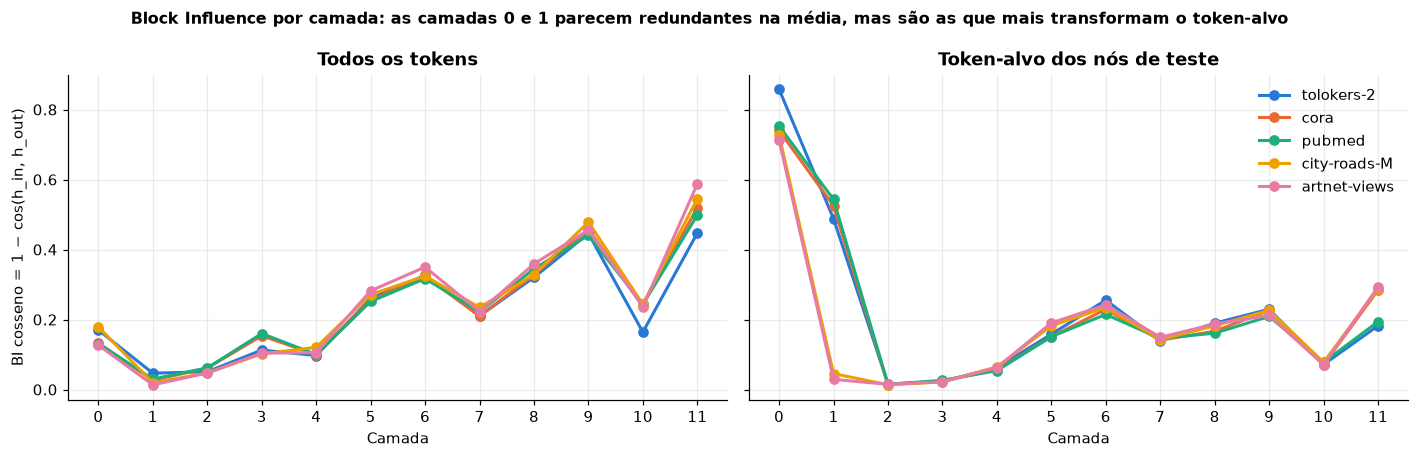

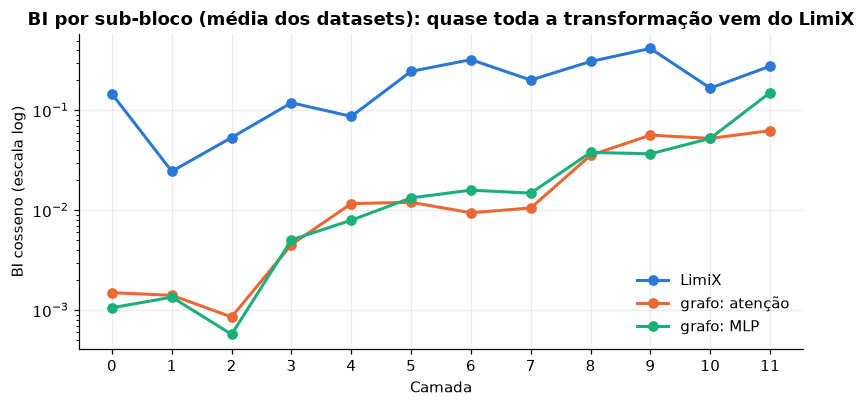

In [8]:
DS_COLOR = {n: COLORS[i] for i, n in enumerate(TASKS)}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, col, title in [(axes[0], "cos_all", "Todos os tokens"),
                       (axes[1], "cos_tgt", "Token-alvo dos nós de teste")]:
    for name in TASKS:
        d = bi_layer[bi_layer.dataset == name]
        ax.plot(d["layer"], d[col], marker="o", color=DS_COLOR[name], label=name)
    ax.set_title(title)
    ax.set_xlabel("Camada")
    ax.set_xticks(range(N_LAYERS))
axes[0].set_ylabel("BI cosseno = 1 − cos(h_in, h_out)")
axes[1].legend(frameon=False)
fig.suptitle("Block Influence por camada: as camadas 0 e 1 parecem redundantes na média, mas são as que mais transformam o token-alvo",
             fontsize=10.5, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bi_por_camada.png", dpi=200, bbox_inches="tight")
plt.show()

sub = bi[bi.bloco.isin(["LimiX", "grafo: atenção", "grafo: MLP"])].groupby(["bloco", "layer"])["cos_all"].mean().reset_index()
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for j, b in enumerate(["LimiX", "grafo: atenção", "grafo: MLP"]):
    d = sub[sub.bloco == b]
    ax.plot(d["layer"], d["cos_all"], marker="o", color=COLORS[j], label=b)
ax.set_yscale("log")
ax.set_xticks(range(N_LAYERS))
ax.set_xlabel("Camada")
ax.set_ylabel("BI cosseno (escala log)")
ax.set_title("BI por sub-bloco (média dos datasets): quase toda a transformação vem do LimiX")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bi_por_subbloco.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
# Estabilidade do ranking de BI
def rank_corr(a, b):
    return spearmanr(a, b).statistic

names = list(TASKS)
cross = pd.DataFrame([[rank_corr(bi_layer[bi_layer.dataset == a]["cos_all"].values,
                                 bi_layer[bi_layer.dataset == b]["cos_all"].values) for b in names] for a in names],
                     index=names, columns=names)
print("Spearman do ranking de BI (cos, todos os tokens) entre datasets:")
display(cross.round(2))

within = pd.DataFrame([{
    "dataset": n,
    "cosseno × angular (todos os tokens)": rank_corr(d["cos_all"], d["ang_all"]),
    "todos os tokens × token-alvo": rank_corr(d["cos_all"], d["cos_tgt"]),
    "5 camadas de menor BI (todos)": sorted(d.nsmallest(5, "cos_all")["layer"].tolist()),
    "5 camadas de menor BI (token-alvo)": sorted(d.nsmallest(5, "cos_tgt")["layer"].tolist()),
} for n, d in ((n, bi_layer[bi_layer.dataset == n]) for n in names)])
display(within.round(2))

Spearman do ranking de BI (cos, todos os tokens) entre datasets:


,tolokers-2,cora,pubmed,city-roads-M,artnet-views
tolokers-2,1.00,0.96,0.96,0.97,0.97
cora,0.96,1.00,1.00,0.98,0.98
pubmed,0.96,1.00,1.00,0.98,0.98
city-roads-M,0.97,0.98,0.98,1.00,1.00
artnet-views,0.97,0.98,0.98,1.00,1.00


,dataset,cosseno × angular (todos os tokens),todos os tokens × token-alvo,5 camadas de menor BI (todos),5 camadas de menor BI (token-alvo)
0,tolokers-2,0.99,0.37,"[1, 2, 3, 4, 10]","[2, 3, 4, 7, 10]"
1,cora,1.00,0.27,"[0, 1, 2, 3, 4]","[2, 3, 4, 7, 10]"
2,pubmed,1.00,0.24,"[0, 1, 2, 3, 4]","[2, 3, 4, 7, 10]"
3,city-roads-M,1.00,0.76,"[0, 1, 2, 3, 4]","[1, 2, 3, 4, 10]"
4,artnet-views,1.00,0.74,"[0, 1, 2, 3, 4]","[1, 2, 3, 4, 10]"


**Como ler.** O ranking de BI é praticamente o mesmo em todos os datasets, e cosseno e angular dão rankings equivalentes (o angular é uma transformação monótona por token). Então trocar cosseno por angular não muda a seleção de camadas. O que muda o ranking é **quais tokens** entram na média: as camadas 0 e 1 têm BI baixo na média geral, mas BI altíssimo no token-alvo. É nelas que a informação das features e dos rótulos de contexto chega ao token que será decodificado.

## 4. Ablação individual: importância real de cada camada (V4)

Cada camada é removida **sozinha**, nas 3 sementes. A queda de desempenho é a importância real da camada. Se o BI for um bom critério, BI baixo deve corresponder a pouca queda (correlação positiva entre BI e importância).

(carregado do cache: ablacao_individual.csv)


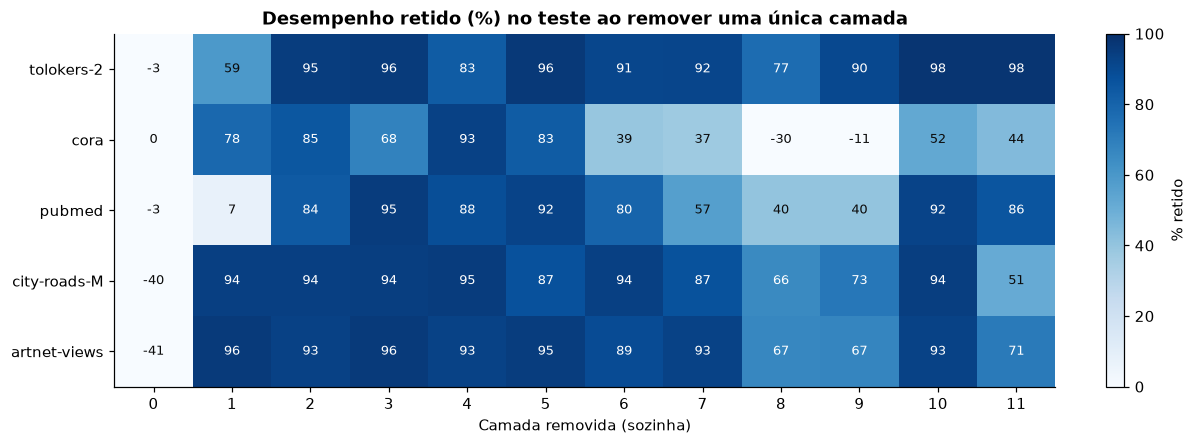

In [10]:
def run_loo():
    rows = []
    for name, t in TASKS.items():
        for layer in range(N_LAYERS):
            for seed in SEEDS:
                s = evaluate(t, seed, remove=[layer])
                bv, bt = BASE_SCORE[(name, seed)]
                rows.append(dict(dataset=name, seed=seed, layer=layer, val=s["val"], test=s["test"],
                                 ret_val=retained(s["val"], bv, t["chance"]),
                                 ret_test=retained(s["test"], bt, t["chance"])))
    return pd.DataFrame(rows)

df_loo = cached("ablacao_individual.csv", run_loo)
loo = df_loo.groupby(["dataset", "layer"], sort=False)[["ret_val", "ret_test", "test"]].mean().reset_index()

mat = loo.pivot(index="dataset", columns="layer", values="ret_test").loc[list(TASKS)]
fig, ax = plt.subplots(figsize=(11, 0.55 * len(mat) + 1.4))
im = ax.imshow(mat.clip(0, 100).values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8.5, color="white" if v > 60 else "#0b0b0b")
ax.set_xticks(range(N_LAYERS))
ax.set_yticks(range(len(mat)))
ax.set_yticklabels(mat.index)
ax.set_xlabel("Camada removida (sozinha)")
ax.set_title("Desempenho retido (%) no teste ao remover uma única camada")
ax.grid(False)
fig.colorbar(im, ax=ax, label="% retido", fraction=0.025)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ablacao_individual.png", dpi=200, bbox_inches="tight")
plt.show()

,dataset,"ρ(BI todos os tokens, importância)","ρ(BI token-alvo, importância)",camada mais importante,camadas com queda < 5%
0,tolokers-2,-0.27,0.55,0,"[3, 5, 10, 11]"
1,cora,0.64,0.46,8,[]
2,pubmed,0.01,0.71,0,[]
3,city-roads-M,0.62,0.82,0,"[3, 4]"
4,artnet-views,0.66,0.75,0,"[1, 3, 5]"


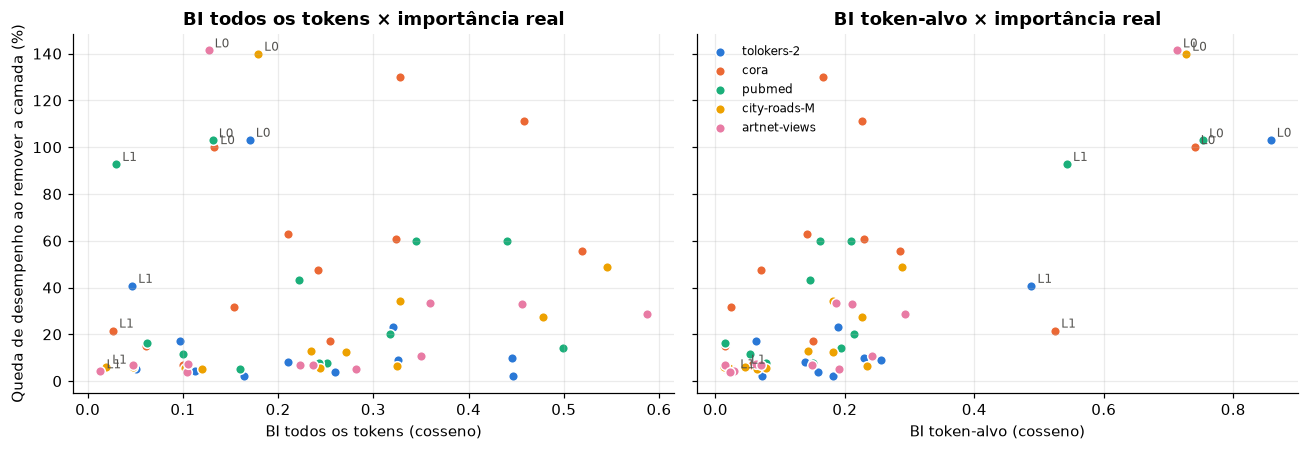

In [11]:
corr_rows = []
for name in TASKS:
    b = bi_layer[bi_layer.dataset == name].set_index("layer")
    l = loo[loo.dataset == name].set_index("layer")
    importance = 100 - l["ret_val"]
    corr_rows.append({
        "dataset": name,
        "ρ(BI todos os tokens, importância)": rank_corr(b["cos_all"], importance),
        "ρ(BI token-alvo, importância)": rank_corr(b["cos_tgt"], importance),
        "camada mais importante": int(importance.idxmax()),
        "camadas com queda < 5%": [int(i) for i in l.index[l["ret_val"] >= 95]],
    })
df_corr = pd.DataFrame(corr_rows)
display(df_corr.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, col, title in [(axes[0], "cos_all", "BI todos os tokens"), (axes[1], "cos_tgt", "BI token-alvo")]:
    for name in TASKS:
        b = bi_layer[bi_layer.dataset == name].set_index("layer")
        l = loo[loo.dataset == name].set_index("layer")
        ax.scatter(b[col], 100 - l["ret_test"].clip(-50, 150), color=DS_COLOR[name], s=40, label=name,
                   edgecolor="white", linewidth=1)
        for lay in [0, 1]:
            ax.annotate(f"L{lay}", (b.loc[lay, col], 100 - min(l.loc[lay, "ret_test"], 150)),
                        fontsize=8, xytext=(4, 2), textcoords="offset points", color="#52514e")
    ax.set_xlabel(f"{title} (cosseno)")
    ax.set_title(f"{title} × importância real")
axes[0].set_ylabel("Queda de desempenho ao remover a camada (%)")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bi_vs_importancia.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Curvas de poda: BI × aleatório × ablação (V2, V3)

Remove-se $k = 1, \dots, 11$ camadas de uma vez (sem re-treino), seguindo quatro ordens:

| Estratégia | Ordem de remoção | Usa rótulos? |
|---|---|---|
| **BI todos os tokens** | menor BI cosseno médio primeiro | não |
| **BI token-alvo** | menor BI cosseno do token-alvo primeiro | não |
| **Ablação individual (val)** | menor queda na validação primeiro | sim, **só validação** |
| **Aleatória** (5 ordens) | permutação aleatória | não |

In [12]:
def strategy_orders(name):
    b = bi_layer[bi_layer.dataset == name].set_index("layer")
    l = loo[loo.dataset == name].set_index("layer")
    orders = {
        "BI todos os tokens": b["cos_all"].sort_values().index.tolist(),
        "BI token-alvo": b["cos_tgt"].sort_values().index.tolist(),
        "Ablação individual (val)": l["ret_val"].sort_values(ascending=False).index.tolist(),
    }
    rng = np.random.default_rng(0)
    for r in range(N_RANDOM_ORDERS):
        orders[f"Aleatória {r}"] = rng.permutation(N_LAYERS).tolist()
    return orders

ORDERS = {name: strategy_orders(name) for name in TASKS}
for name in TASKS:
    print(name, {k: v for k, v in ORDERS[name].items() if not k.startswith("Aleatória")})

def run_curves():
    rows = []
    for name, t in TASKS.items():
        for strat, order in ORDERS[name].items():
            seeds = SEEDS[:1] if strat.startswith("Aleatória") else SEEDS
            for k in range(1, N_LAYERS):
                for seed in seeds:
                    s = evaluate(t, seed, remove=order[:k])
                    bv, bt = BASE_SCORE[(name, seed)]
                    rows.append(dict(dataset=name, estrategia=strat, k=k, seed=seed, removidas=str(sorted(order[:k])),
                                     val=s["val"], test=s["test"],
                                     ret_test=retained(s["test"], bt, t["chance"])))
    return pd.DataFrame(rows)

df_curves = cached("curvas_poda.csv", run_curves)

tolokers-2 {'BI todos os tokens': [1, 2, 4, 3, 10, 0, 7, 5, 8, 6, 9, 11], 'BI token-alvo': [2, 3, 4, 10, 7, 5, 11, 8, 9, 6, 1, 0], 'Ablação individual (val)': [11, 10, 5, 3, 2, 6, 7, 9, 4, 8, 1, 0]}
cora {'BI todos os tokens': [1, 2, 4, 0, 3, 7, 10, 5, 6, 8, 9, 11], 'BI token-alvo': [2, 3, 4, 10, 7, 5, 8, 9, 6, 11, 1, 0], 'Ablação individual (val)': [4, 2, 1, 5, 3, 11, 10, 7, 6, 0, 9, 8]}
pubmed {'BI todos os tokens': [1, 2, 4, 0, 3, 7, 10, 5, 6, 8, 9, 11], 'BI token-alvo': [2, 3, 4, 10, 7, 5, 8, 11, 9, 6, 1, 0], 'Ablação individual (val)': [5, 4, 10, 3, 2, 6, 11, 7, 9, 8, 1, 0]}
city-roads-M {'BI todos os tokens': [1, 2, 3, 4, 0, 7, 10, 5, 6, 8, 9, 11], 'BI token-alvo': [2, 3, 1, 4, 10, 7, 5, 8, 9, 6, 11, 0], 'Ablação individual (val)': [4, 3, 10, 1, 2, 6, 7, 5, 9, 8, 11, 0]}
artnet-views {'BI todos os tokens': [1, 2, 3, 4, 0, 7, 10, 5, 6, 8, 9, 11], 'BI token-alvo': [2, 3, 1, 4, 10, 7, 8, 5, 9, 6, 11, 0], 'Ablação individual (val)': [1, 3, 5, 2, 7, 4, 10, 6, 11, 9, 8, 0]}
(carregado 

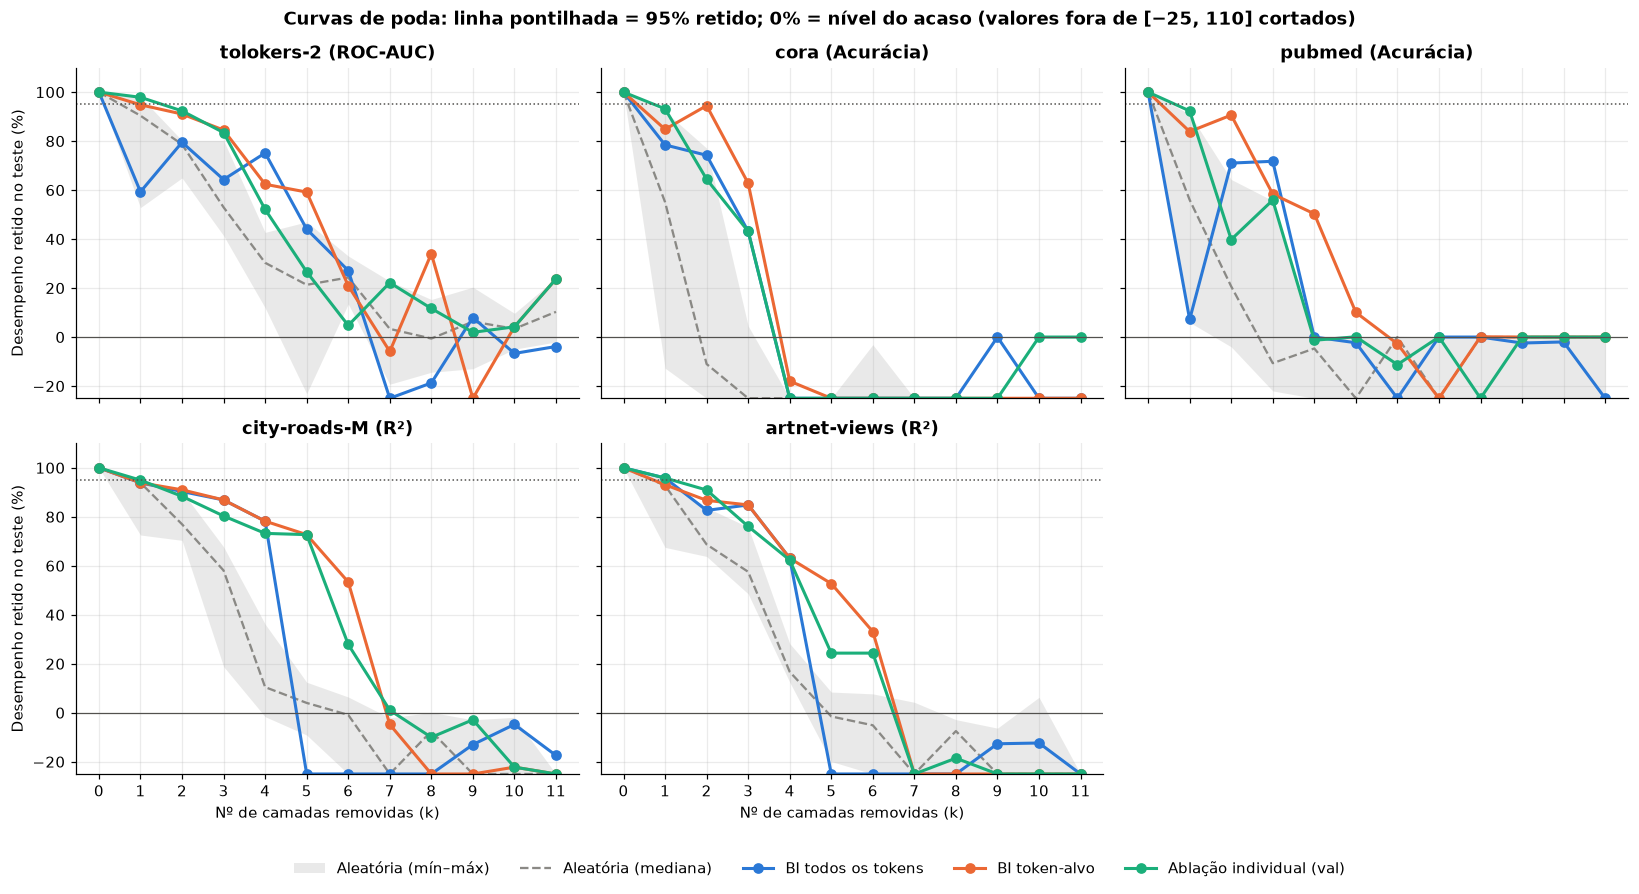

In [13]:
MAIN = ["BI todos os tokens", "BI token-alvo", "Ablação individual (val)"]
STRAT_COLOR = {s: COLORS[i] for i, s in enumerate(MAIN)}
cur = df_curves.groupby(["dataset", "estrategia", "k"])["ret_test"].mean().reset_index()

n = len(TASKS)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True, sharey=True, squeeze=False)
for ax, name in zip(axes.flat, TASKS):
    d = cur[cur.dataset == name]
    rnd = d[d.estrategia.str.startswith("Aleatória")].groupby("k")["ret_test"]
    ks = np.arange(0, N_LAYERS)
    lo = np.r_[100, rnd.min().values]; hi = np.r_[100, rnd.max().values]; med = np.r_[100, rnd.median().values]
    ax.fill_between(ks, lo.clip(-25, 110), hi.clip(-25, 110), color=GRAY, alpha=0.18, lw=0, label="Aleatória (mín–máx)")
    ax.plot(ks, med.clip(-25, 110), color=GRAY, ls="--", lw=1.5, label="Aleatória (mediana)")
    for s in MAIN:
        y = np.r_[100, d[d.estrategia == s].sort_values("k")["ret_test"].values]
        ax.plot(ks, y.clip(-25, 110), marker="o", color=STRAT_COLOR[s], label=s)
    ax.axhline(95, color="#52514e", lw=1, ls=":")
    ax.axhline(0, color="#52514e", lw=0.8)
    ax.set_title(f"{name} ({METRIC_LABEL[TASKS[name]['metric']]})")
    ax.set_ylim(-25, 110)
    ax.set_xticks(ks)
for ax in axes[-1]:
    ax.set_xlabel("Nº de camadas removidas (k)")
for ax in axes[:, 0]:
    ax.set_ylabel("Desempenho retido no teste (%)")
for ax in list(axes.flat)[n:]:
    ax.axis("off")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Curvas de poda: linha pontilhada = 95% retido; 0% = nível do acaso (valores fora de [−25, 110] cortados)",
             fontweight="bold")
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.savefig(RESULTS_DIR / "curvas_poda.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Custo: parâmetros e latência

In [14]:
lat_name = max(TASKS, key=lambda n: TASKS[n]["ds"].n_nodes)
t = TASKS[lat_name]
rows = []
for k in [0, 2, 4, 6, 8, 10]:
    remove = list(range(N_LAYERS - k, N_LAYERS))
    evaluate(t, SEEDS[0], remove)  # aquecimento
    times = []
    for _ in range(3):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        tic = time.time()
        evaluate(t, SEEDS[0], remove)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.time() - tic)
    rows.append(dict(k=k, camadas=N_LAYERS - k, params_M=(P_TOTAL - k * P_LAYER) / 1e6,
                     reducao_params_pct=100 * k * P_LAYER / P_TOTAL, latencia_s=np.median(times)))
df_cost = pd.DataFrame(rows)
df_cost["reducao_latencia_pct"] = 100 * (1 - df_cost["latencia_s"] / df_cost.loc[0, "latencia_s"])
print(f"Latência medida em '{lat_name}' ({t['ds'].n_nodes} nós), mediana de 3 execuções, inclui pré/pós-processamento do forward")
display(df_cost.round(3))
df_cost.to_csv(RESULTS_DIR / "custo_poda.csv", index=False)

Latência medida em 'city-roads-M' (57073 nós), mediana de 3 execuções, inclui pré/pós-processamento do forward


,k,camadas,params_M,reducao_params_pct,latencia_s,reducao_latencia_pct
0,0,12,20.091,0.000,4.124,0.000
1,2,10,16.842,16.168,3.432,16.772
2,4,8,13.594,32.336,2.794,32.258
3,6,6,10.346,48.504,2.137,48.174
4,8,4,7.098,64.672,1.480,64.102
5,10,2,3.849,80.840,0.822,80.069


## 7. Veredito

Para cada dataset e estratégia: o maior $k$ em que o desempenho retido médio fica ≥ 99% e ≥ 95%. Em seguida, cada critério V1 a V4 é checado automaticamente.

In [15]:
def max_k(d, thr):
    ok = d[d["ret_test"] >= thr]["k"]
    return int(ok.max()) if len(ok) else 0

ver = []
for name in TASKS:
    for s in MAIN + ["Aleatória (mediana)"]:
        if s.startswith("Aleatória"):
            d = cur[(cur.dataset == name) & cur.estrategia.str.startswith("Aleatória")].groupby("k")["ret_test"].median().reset_index()
        else:
            d = cur[(cur.dataset == name) & (cur.estrategia == s)]
        ver.append(dict(dataset=name, estrategia=s, k_max_99=max_k(d, 99), k_max_95=max_k(d, 95),
                        retido_k3=float(d[d.k == 3]["ret_test"].iloc[0])))
df_ver = pd.DataFrame(ver)
display(df_ver.pivot(index="dataset", columns="estrategia", values="k_max_95")[MAIN + ["Aleatória (mediana)"]]
        .style.set_caption("Maior nº de camadas removíveis mantendo ≥ 95% do desempenho"))
display(df_ver.pivot(index="dataset", columns="estrategia", values="retido_k3")[MAIN + ["Aleatória (mediana)"]].round(1)
        .style.set_caption("Desempenho retido (%) removendo 3 camadas"))
df_ver.to_csv(RESULTS_DIR / "veredito.csv", index=False)

base_ok = all(summary.set_index("dataset").loc[n, "test_media"] > TASKS[n]["chance"] + 0.05 for n in TASKS)
bi_all = df_ver[df_ver.estrategia == MAIN[0]].set_index("dataset")["retido_k3"]
rnd_med = df_ver[df_ver.estrategia == "Aleatória (mediana)"].set_index("dataset")["retido_k3"]
rho = df_corr["ρ(BI todos os tokens, importância)"]

print("V1  Baseline funciona:", "SIM" if base_ok else "NÃO",
      "| teste médio:", {n: round(v, 3) for n, v in summary.set_index("dataset")["test_media"].items()})
best_k = df_ver[df_ver.estrategia.isin(MAIN)].groupby("dataset")["k_max_95"].max()
print(f"V2  Maior nº de camadas removíveis com ≥ 95% retido (melhor estratégia): {best_k.to_dict()} →",
      "poda viável" if best_k.min() >= 2 else f"no máximo {best_k.max()} camada(s)")
print(f"V3  BI (todos os tokens) melhor que aleatório com k=3 em {(bi_all > rnd_med).sum()}/{len(bi_all)} datasets "
      f"(BI: {bi_all.mean():.1f}% retido vs aleatório: {rnd_med.mean():.1f}%)")
print(f"V4  ρ(BI, importância real) médio = {rho.mean():.2f} (positivo = BI funciona como critério; ≤ 0 = não funciona)")

estrategia,BI todos os tokens,BI token-alvo,Ablação individual (val),Aleatória (mediana)
dataset,,,,
artnet-views,1,0,1,0
city-roads-M,0,0,0,0
cora,0,0,0,0
pubmed,0,0,0,0
tolokers-2,0,0,1,0


estrategia,BI todos os tokens,BI token-alvo,Ablação individual (val),Aleatória (mediana)
dataset,,,,
artnet-views,84.800000,84.800000,76.100000,57.500000
city-roads-M,86.900000,86.900000,80.300000,58.100000
cora,43.200000,62.800000,43.200000,-37.600000
pubmed,71.800000,58.400000,55.900000,-10.700000
tolokers-2,64.300000,84.500000,83.500000,53.000000


V1  Baseline funciona: SIM | teste médio: {'tolokers-2': 0.859, 'cora': 0.674, 'pubmed': 0.714, 'city-roads-M': 0.64, 'artnet-views': 0.621}
V2  Maior nº de camadas removíveis com ≥ 95% retido (melhor estratégia): {'artnet-views': 1, 'city-roads-M': 0, 'cora': 0, 'pubmed': 0, 'tolokers-2': 1} → no máximo 1 camada(s)
V3  BI (todos os tokens) melhor que aleatório com k=3 em 5/5 datasets (BI: 70.2% retido vs aleatório: 24.1%)
V4  ρ(BI, importância real) médio = 0.33 (positivo = BI funciona como critério; ≤ 0 = não funciona)


## 8. Conclusões

Valores de referência da execução com 5 datasets × 3 sementes (CSVs em `Block_Influence_results/graphfpn_analise_unificada/`).

### 8.1 O baseline funciona (V1)

| Dataset | Métrica | Modelo completo | Acaso |
|---|---|---|---|
| tolokers-2 | ROC-AUC | **0,860** | 0,50 |
| cora | Acurácia | **0,674** | 0,32 |
| pubmed | Acurácia | **0,714** | 0,41 |
| city-roads-M | R² | **0,640** | 0 |
| artnet-views | R² | **0,621** | 0 |

Com o pipeline oficial, o modelo completo fica bem acima do acaso em todos os datasets e varia muito pouco entre sementes (desvio ≤ 0,01). Esse é o ponto de referência de todas as comparações de poda.

### 8.2 O que acontece dentro das camadas

- **Quase toda a transformação vem do bloco LimiX.** Os adaptadores de grafo (atenção + MLP, 18% dos parâmetros de cada camada) alteram o estado muito pouco (BI 0,001–0,06), com exceção do MLP de grafo da camada 11 (0,15).
- **O ranking de BI é praticamente o mesmo em todos os datasets**, e cosseno e angular são equivalentes (Spearman ≈ 1). A escolha da métrica não muda nada.
- **A média sobre todos os tokens esconde as camadas críticas.** As camadas 0 e 1 têm BI baixo na média, mas no token-alvo são as que mais mudam (0,71–0,86 na camada 0). É nelas que a informação das features e do contexto rotulado chega ao token decodificado.
- **A camada 0 é indispensável:** removê-la sozinha leva **todos** os datasets ao nível do acaso ou abaixo (−41% a 0% retido).
- **A camada 1 é crítica para classificação e dispensável para regressão:** retém 7% no pubmed e 59% no tolokers, mas 94–96% em city-roads-M e artnet-views. O BI do token-alvo antecipa isso (≈0,5 em classificação, ≈0,03 em regressão).

### 8.3 BI ajuda a ordenar as camadas, mas não permite podar sem perda (V3, V4)

- **V3 (melhor que aleatório): sim.** Removendo 3 camadas, a ordem por BI retém 70% em média contra 24% da mediana aleatória, e vence nos 5/5 datasets.
- **V4 (correlação com a importância real): fraca com todos os tokens, moderada no token-alvo.** O ρ de Spearman médio entre BI e queda na ablação é 0,33 com todos os tokens (−0,27 no tolokers-2) e **0,66 com o token-alvo**. O BI no token-alvo é o critério mais coerente com o funcionamento do modelo.
- **Mas nenhuma estratégia passa do limite de 95% além de k = 1**, e isso inclui a ablação, que escolhe camadas olhando rótulos de validação. Com 1 camada removida, o máximo é ≈ 93–98% retido (camada 11 no tolokers-2, camada 1 nos datasets de regressão). Com 2–3 camadas, a queda já é de 10% a 50%, e a partir de 5 o modelo colapsa na maioria dos datasets.

### 8.4 Veredito

| Critério | Resultado |
|---|---|
| V1 Baseline válido | ✅ |
| V2 Poda retém ≥ 95% | ❌ no máximo 1 camada (≈ 8% dos parâmetros e da latência) passa no limite; remover as 5 camadas de menor BI (incluindo a 0) leva 4 de 5 datasets ao nível do acaso ou abaixo |
| V3 BI melhor que aleatório | ✅ |
| V4 BI reflete a importância real | ⚠️ parcialmente: ρ = 0,33 (todos os tokens), 0,66 (token-alvo) |

**Remover camadas inteiras do GraphPFN escolhidas por Block Influence, sem re-treino, não é uma poda válida além de 1 camada.** O ganho de custo é linear (cada camada vale ≈ 8% dos parâmetros e ≈ 8% da latência), mas a perda de desempenho cresce muito mais rápido. Ao contrário dos LLMs, onde o ShortGPT encontra camadas quase redundantes, as 12 camadas do LimiX-16M são todas usadas.

### 8.5 Próximos passos, se a ideia for seguir com poda

1. **Usar BI do token-alvo** (ou ablação na validação) como critério, e nunca remover as camadas 0 e 1 em classificação.
2. **Recuperar o desempenho após a poda** com fine-tuning curto (`graphpfn.inference.finetune` já existe no pacote) ou destilação do modelo completo, e repetir as curvas da Seção 5.
3. **Podar em granularidade menor**: sub-blocos dentro do `fmfmsm` (atenções e MLPs individuais) ou cabeças de atenção, em vez da camada inteira.